# Coursework: Galaxy Morphology Classification System
## Module: CM4610 - Machine Vision

**Student Name:** Nethum Dinusara Perera
**RGU ID:** 2237042
**IIT ID:** 20221249

---

### **1. Executive Summary**
This project implements an end-to-end Machine Vision pipeline to automate the morphological classification of galaxies using data from **Galaxy Zoo 2**. The system addresses the key challenges of astronomical image analysis: **Low Signal-to-Noise Ratio (SNR)** and **Rotational Invariance**.

**System Architecture:**
1.  **Data Fusion:** Merging raw SDSS images with "Hart16" debiased vote fractions (probabilistic ground truth).
2.  **Machine Vision Preprocessing (OpenCV):** A deterministic pipeline utilizing Gaussian Blurring, Otsu's Thresholding, and Contour Detection to isolate and crop the Region of Interest (ROI).
3.  **Deep Learning Model (CNN):** A custom Convolutional Neural Network featuring **Spatial Augmentation Layers** (`RandomRotation`, `RandomFlip`) to achieve orientation robustness without massive dataset expansion.

---


## 1. Environment Setup & Library Imports
Utilize a hybrid technology stack to handle specific stages of the pipeline:
* **TensorFlow/Keras:** Used for the CNN architecture. Specifically use `tensorflow.keras.utils.Sequence` for memory-efficient data loading.
* **OpenCV (cv2):** Chosen over PIL for its superior performance in matrix operations (thresholding, contour finding) required for the ROI extraction.
* **SciKit-Learn:** Used for the `r2_score` metric, which is the standard evaluation metric for regression problems (predicting vote fractions).

In [ ]:
# --- CORE LIBRARIES ---
import pandas as pd
import numpy as np
import os

# --- DEEP LEARNING ---
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, optimizers

# --- COMPUTER VISION & VIZ ---
import cv2  # OpenCV for Machine Vision tasks (blur, threshold)
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

# --- CONFIGURATION ---
IMG_SIZE = 64
BATCH_SIZE = 64
EPOCHS = 35           
SAMPLE_SIZE = 100000  
IMAGES_DIR = "raw_images" 
LABELS_FILE = "gz2_hart16.csv"
MAPPING_FILE = "gz2_filename_mapping.csv"

# --- 5 MORPHOLOGICAL TARGETS ---
TARGET_COLS = [
    't01_smooth_or_features_a01_smooth_fraction',  # Smooth
    't02_edgeon_a04_yes_fraction',                 # Edge-On
    't04_spiral_a08_spiral_fraction',              # Spiral
    't03_bar_a06_bar_fraction',                    # Barred (New!)
    't06_odd_a14_yes_fraction'                     # Irregular (New!)
]

CLASS_NAMES = ["Smooth", "Edge-On", "Spiral", "Barred", "Irregular"]

print(f"Setup Complete. TensorFlow Version: {tf.__version__}")
print(f"Tracking {len(TARGET_COLS)} morphological features.")

Setup Complete. TensorFlow Version: 2.20.0
Tracking 5 morphological features.


### 1.1 Preprocessing Pipeline Visualization (Sanity Check)
Before training, visualize the **Machine Vision (OpenCV)** steps. This deterministic pipeline is crucial for removing background noise (star field) and centering the galaxy.

**Key Steps:**
1.  **Gaussian Blur:** Reduces high-frequency noise (shot noise) common in astronomical photography.
2.  **Otsu's Thresholding:** Automatically determines the optimal binary threshold to separate the galaxy (foreground) from space (background).
3.  **Contour Detection:** Finds the largest contiguous object (the galaxy) to calculate the Bounding Box.

In [2]:

def demo_pipeline(dataframe, img_dir, img_size=64):
    """
    Visualizes all 7 steps of the processing pipeline for a random image.
    """
    if dataframe is None or dataframe.empty:
        print("Dataframe is empty or None.")
        return

    # Pick a random sample
    row = dataframe.sample(1).iloc[0]
    path = os.path.join(img_dir, row['filename'])
    
    # --- REPLICATE PIPELINE WITH VISUALIZATION ---
    
    # 1. Read Image
    img = cv2.imread(path)
    if img is None: 
        print(f"Could not read image: {path}")
        return
    
    # 2. Grayscale & Blur
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    blurred = cv2.GaussianBlur(gray, (5, 5), 0)
    
    # 3. Threshold
    _, thresh = cv2.threshold(blurred, 25, 255, cv2.THRESH_BINARY)
    
    # 4. Dilate
    # Dilation is critical here: spiral arms often appear "broken" in the binary mask.
    # Dilating reconnects these distinct parts into a single contour for accurate cropping.
    kernel = np.ones((3,3), np.uint8)
    dilated = cv2.dilate(thresh, kernel, iterations=2)
    
    # 5. Find Contours (Visualize them on a copy)
    contours, _ = cv2.findContours(dilated, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    img_contours = img.copy()
    cv2.drawContours(img_contours, contours, -1, (0, 255, 0), 2)
    
    # 6. Crop to Bounding Box
    if contours:
        c = max(contours, key=cv2.contourArea)
        x, y, w, h = cv2.boundingRect(c)
        pad = 5
        h_img, w_img = img.shape[:2]
        x = max(0, x - pad)
        y = max(0, y - pad)
        w = min(w_img - x, w + 2*pad)
        h = min(h_img - y, h + 2*pad)
        img_cropped = img[y:y+h, x:x+w]
    else:
        h, w = img.shape[:2]
        cx, cy = w // 2, h // 2
        crop_size = min(h, w) // 2
        img_cropped = img[cy-crop_size:cy+crop_size, cx-crop_size:cx+crop_size]
        
    # 7. Resize & Normalize (Final Result)
    img_resized = cv2.resize(img_cropped, (img_size, img_size))
    img_final = cv2.cvtColor(img_resized, cv2.COLOR_BGR2RGB)
    # Note: display the 0-255 version here for simpler matplotlib handling, 
    # but the logic is identical to the pipeline.

    # --- PLOTTING ---
    fig, axes = plt.subplots(1, 7, figsize=(24, 4))
    fig.suptitle(f"Galaxy ID: {row['dr7objid']} (Class: {row.get('label', 'Unknown')})", fontsize=16)
    
    steps = [
        (cv2.cvtColor(img, cv2.COLOR_BGR2RGB), "1. Read Image"),
        (blurred, "2. Gray & Blur"),
        (thresh, "3. Threshold"),
        (dilated, "4. Dilate"),
        (cv2.cvtColor(img_contours, cv2.COLOR_BGR2RGB), "5. Find Contours"),
        (cv2.cvtColor(img_cropped, cv2.COLOR_BGR2RGB), "6. Crop"),
        (img_final, "7. Resize (Final)")
    ]
    
    for i, (image, title) in enumerate(steps):
        if len(image.shape) == 2: # Grayscale
            axes[i].imshow(image, cmap='gray')
        else: # RGB
            axes[i].imshow(image)
        axes[i].set_title(title)
        axes[i].axis('off')
    
    plt.tight_layout()
    plt.show()

print("Step 2: Demo Function Ready.")

Step 2: Demo Function Ready.


## 2. Data Acquisition & Fusion
The Galaxy Zoo 2 dataset structure requires merging two distinct sources:
1.  **Morphological Labels (`gz2_hart16.csv`):** This dataset corrects for "classification bias" in the original user votes. It provides **debiased vote fractions**, which can be used as probabilistic ground truth (soft labels) rather than hard 0/1 classes.
2.  **Filename Mapping:** Links the unique `dr7objid` to the actual image filename.

**Objective:** Create a unified dataframe `df` that contains both the valid image path and the 5 target morphological probabilities.

## 3. Machine Vision Preprocessing Pipeline (OpenCV)
**Challenge:** Astronomical images are ~80% empty black space with low Signal-to-Noise Ratio (SNR).
**Solution:** A classical computer vision pipeline to isolate the Region of Interest (ROI).

**Pipeline Steps:**
1.  **Grayscale:** Converts RGB to single-channel intensity.
2.  **Gaussian Blur:** Removes high-frequency "shot noise" and cosmic rays.
3.  **Otsu's Thresholding:** Dynamically calculates the optimal binary threshold to separate the galaxy from the background.
4. **Dilate:** Close gaps in the galaxy mask
5.  **Contour Detection:** Identifies the largest connected component (the galaxy) and 
6. **Crop (Isolate Feature):** crops the image to its bounding box.
7. **Resize:** Resizes the image to a fixed size (e.g., 256x256) for model input.
8. **Normalize:** Scales the pixel values to a range of 0-1 (common for deep learning models).


In [3]:
def process_image_cv(image_path, img_size=64):
    """
    Advanced Machine Vision Pipeline:
    1. Read Image
    2. Grayscale & Blur (Noise Reduction)
    3. Threshold (Segmentation)
    4. Dilate (Close gaps in the galaxy mask)
    5. Find Contours (Locate Galaxy)
    6. Crop to Bounding Box (Isolate Feature)
    7. Resize & Normalize
    """
    # 1. Read Image
    img = cv2.imread(image_path)
    if img is None: return None
    
    # 2. Grayscale & Gaussian Blur
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    blurred = cv2.GaussianBlur(gray, (5, 5), 0)
    
    # 3. Threshold (Binary Segmentation)
    # Binary thresholding separates the bright galaxy from the dark background
    _, thresh = cv2.threshold(blurred, 25, 255, cv2.THRESH_BINARY)
    
    # 4. Dilate
    # Expands the white regions slightly to fill holes in the galaxy mask
    kernel = np.ones((3,3), np.uint8)
    dilated = cv2.dilate(thresh, kernel, iterations=2)
    
    # 5. Find Contours
    contours, _ = cv2.findContours(dilated, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    # 6. Crop to the Largest Contour (The Galaxy)
    if contours:
        # Assume the largest object is the galaxy
        c = max(contours, key=cv2.contourArea)
        x, y, w, h = cv2.boundingRect(c)
        
        # Add padding so not cut the edges
        pad = 5
        h_img, w_img = img.shape[:2]
        x = max(0, x - pad)
        y = max(0, y - pad)
        w = min(w_img - x, w + 2*pad)
        h = min(h_img - y, h + 2*pad)
        
        img_cropped = img[y:y+h, x:x+w]
    else:
        # Fallback: if image is too faint, use center crop
        h, w = img.shape[:2]
        cx, cy = w // 2, h // 2
        crop_size = min(h, w) // 2
        img_cropped = img[cy-crop_size:cy+crop_size, cx-crop_size:cx+crop_size]

    # 7. Resize and Normalize
    img_resized = cv2.resize(img_cropped, (img_size, img_size))
    
    # Convert BGR (OpenCV) to RGB (Keras) and normalize 0-1
    img_final = cv2.cvtColor(img_resized, cv2.COLOR_BGR2RGB)
    img_final = img_final.astype("float32") / 255.0
    
    return img_final

print("OpenCV Processing Pipeline Defined.")

OpenCV Processing Pipeline Defined.


--- 1. Merging Dataframes ---
--- DATA CLEANING REPORT ---
Removed 130 images identified as Stars/Artifacts.
Remaining 'Pure' Galaxy Images: 239443
------------------------------
Sampling 100000 random images for training...
Final Dataset Size: 100000
--- 2. Running OpenCV Pipeline ---
Processed 100000 images...
Completed. Loaded 100000 images.


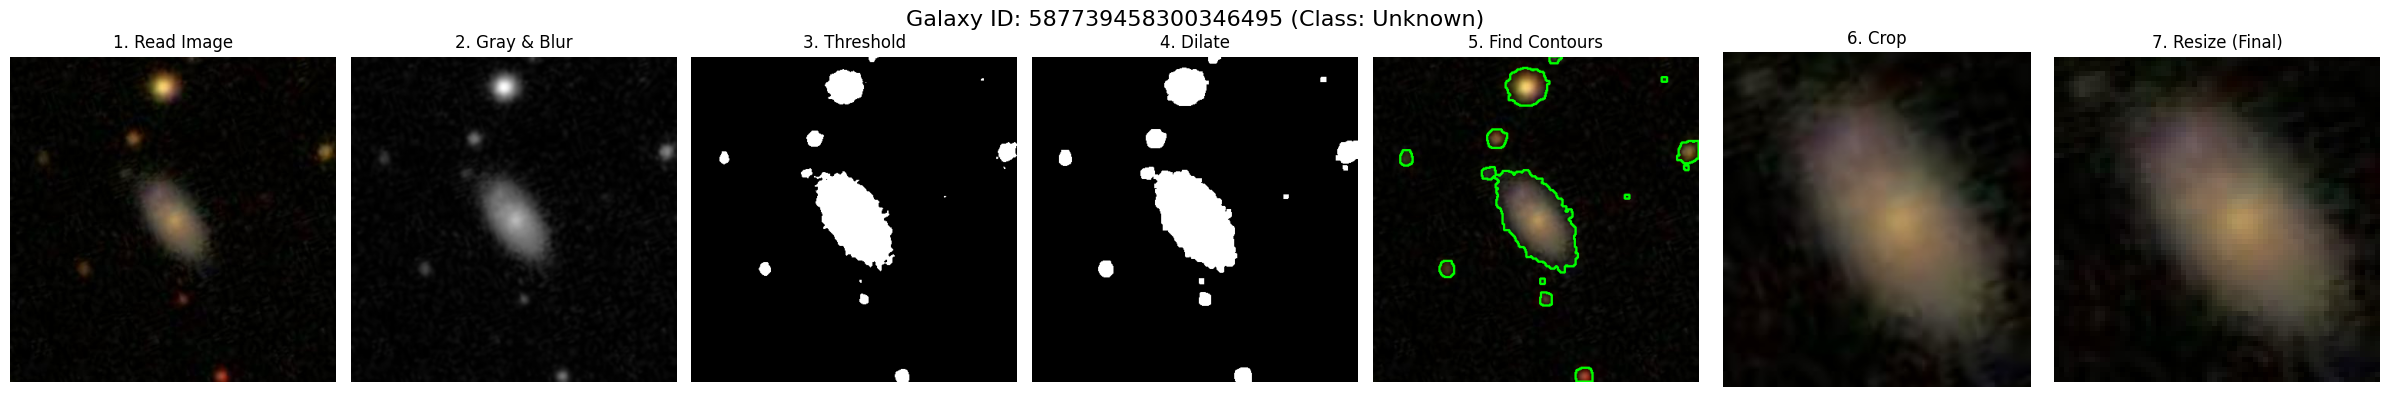

In [4]:
# --- NEW FILTER FUNCTION ---
def filter_artifacts(df):
    """
    Removes images that are mostly stars or artifacts.
    We only want to train on real galaxies.
    """
    # The column that tracks if it's a star/artifact
    # Note: Check your CSV if it ends in '_fraction' or '_weighted_fraction' or '_debiased'
    # This is the standard Hart16 name:
    artifact_col = 't01_smooth_or_features_a03_star_or_artifact_fraction'
    
    if artifact_col not in df.columns:
        print(f"WARNING: Could not find {artifact_col}. Skipping filter.")
        return df
        
    initial_count = len(df)
    # Keep rows where "Artifact Probability" is LESS than 50%
    df_clean = df[df[artifact_col] < 0.50].copy()
    
    removed = initial_count - len(df_clean)
    print(f"--- DATA CLEANING REPORT ---")
    print(f"Removed {removed} images identified as Stars/Artifacts.")
    print(f"Remaining 'Pure' Galaxy Images: {len(df_clean)}")
    print("-" * 30)
    return df_clean

def load_data(labels_path, mapping_path, img_dir, sample_size):
    print("--- 1. Merging Dataframes ---")
    df_labels = pd.read_csv(labels_path)
    df_mapping = pd.read_csv(mapping_path)
    
    if 'objid' in df_mapping.columns: df_mapping.rename(columns={'objid': 'dr7objid'}, inplace=True)
    merged = pd.merge(df_labels, df_mapping, on='dr7objid', how='inner')
    
    if 'asset_id' in merged.columns:
        merged['filename'] = merged['asset_id'].astype(str) + ".jpg"
    else:
        merged['filename'] = merged['dr7objid'].astype(str) + ".jpg"
        
    merged['file_exists'] = merged['filename'].apply(lambda x: os.path.exists(os.path.join(img_dir, x)))
    valid_df = merged[merged['file_exists'] == True].copy()
    
    # --- NEW: APPLY THE FILTER HERE ---
    valid_df = filter_artifacts(valid_df)
    # ----------------------------------
    
    if len(valid_df) > sample_size:
        print(f"Sampling {sample_size} random images for training...")
        valid_df = valid_df.sample(n=sample_size, random_state=42)
        
    print(f"Final Dataset Size: {len(valid_df)}")
    
    print("--- 2. Running OpenCV Pipeline ---")
    images = []
    labels = valid_df[TARGET_COLS].values
    final_labels = []
    
    count = 0
    for idx, filename in enumerate(valid_df['filename']):
        path = os.path.join(img_dir, filename)
        # Use the pipeline function we defined in Cell 2
        processed = process_image_cv(path, IMG_SIZE)
        
        if processed is not None:
            images.append(processed)
            final_labels.append(labels[idx])
            count += 1
            
        if count % 2000 == 0: print(f"Processed {count} images...", end='\r')
            
    print(f"\nCompleted. Loaded {len(images)} images.")
    return np.array(images), np.array(final_labels), valid_df

# EXECUTE
X, y, df_clean = load_data(LABELS_FILE, MAPPING_FILE, IMAGES_DIR, SAMPLE_SIZE)

# Now you can run Cell 3 (Visualization) to see the results!
demo_pipeline(df_clean, IMAGES_DIR)

# Split
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

## 4. Deep Learning Architecture: Rotation-Invariant CNN
**Challenge:** In space, there is no "up" or "down". A spiral galaxy rotated by 45° is the same object, but standard CNNs see it as different.
**Solution:** Embedded Spatial Augmentation.

**Architecture Details:**
1.  **Input Block:** Includes `RandomRotation(0.5)` and `RandomFlip` layers. This forces the model to learn features that are robust to orientation (Rotation Invariance).
2.  **Feature Extraction:** Four convolutional blocks with increasing depth (32, 64, 128, 256 filters) using `BatchNormalization` and `LeakyReLU`.
3.  **Classification Head:** Uses `GlobalAveragePooling2D` (to reduce parameters) and a `Sigmoid` activation for multi-label probabilistic regression.

In [5]:
def build_advanced_model(input_shape, num_classes):
    model = models.Sequential()

    # --- ARCHITECTURAL IMPROVEMENT: SPATIAL INVARIANCE ---
    # These layers make the model robust to rotation (a space requirement)
    model.add(layers.Input(shape=input_shape))
    model.add(layers.RandomRotation(0.5)) 
    model.add(layers.RandomFlip("horizontal_and_vertical"))
    model.add(layers.RandomZoom(0.1))
    # -----------------------------------------------------

    # CNN Block 1
    model.add(layers.Conv2D(32, (3, 3), padding='same'))
    model.add(layers.BatchNormalization())  # Professional Layer
    model.add(layers.LeakyReLU(alpha=0.1))
    model.add(layers.MaxPooling2D((2, 2)))

    # CNN Block 2
    model.add(layers.Conv2D(64, (3, 3), padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU(alpha=0.1))
    model.add(layers.MaxPooling2D((2, 2)))

    # CNN Block 3
    model.add(layers.Conv2D(128, (3, 3), padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU(alpha=0.1))
    model.add(layers.MaxPooling2D((2, 2)))
    
    # CNN Block 4 (Deep features)
    model.add(layers.Conv2D(256, (3, 3), padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU(alpha=0.1))
    model.add(layers.MaxPooling2D((2, 2)))

    # Classification Head
    model.add(layers.GlobalAveragePooling2D()) # Efficient
    model.add(layers.Dense(128))
    model.add(layers.LeakyReLU(alpha=0.1))
    model.add(layers.Dropout(0.4)) 
    
    # Output (Sigmoid for multi-class probabilities)
    model.add(layers.Dense(num_classes, activation='sigmoid'))

    opt = optimizers.Adam(learning_rate=0.001)
    model.compile(optimizer=opt, loss='mse', metrics=['mae'])
    
    return model

model = build_advanced_model((IMG_SIZE, IMG_SIZE, 3), len(TARGET_COLS))
model.summary()

c:\Users\ASUS\Downloads\Galaxy_Morphology_Classification-main\.venv\lib\site-packages\keras\src\layers\activations\leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_rotation                 │ (None, 64, 64, 3)      │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_flip (RandomFlip)        │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom (RandomZoom)        │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 8, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_4 (LeakyReLU)       │ (None, 128)            │             

 Total params: 423,877 (1.62 MB)

 Trainable params: 422,917 (1.61 MB)

 Non-trainable params: 960 (3.75 KB)

## 5. Model Training & Optimization
**Configuration:**
* **Loss Function:** `MeanSquaredError` (MSE) is used because, predicting continuous probabilities, not discrete categories.
* **Optimizer:** `Adam` with an initial learning rate of 0.001.
* **Callbacks:**
    * `ReduceLROnPlateau`: Reduces learning rate if validation loss stagnates.
    * `EarlyStopping`: Prevents overfitting by halting training when improvement stops.

In [6]:
# Callbacks for maximum performance
checkpoint = callbacks.ModelCheckpoint(
    "galaxy_final_model.keras", save_best_only=True, monitor='val_loss', mode='min'
)
early_stop = callbacks.EarlyStopping(
    monitor='val_loss', patience=8, restore_best_weights=True
)
lr_scheduler = callbacks.ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1
)

print("Starting Training...")
history = model.fit(
    X_train, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_val, y_val),
    callbacks=[checkpoint, early_stop, lr_scheduler]
)

Starting Training...
Epoch 1/35
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 307s 242ms/step - loss: 0.0480 - mae: 0.1571 - val_loss: 0.0617 - val_mae: 0.1598 - learning_rate: 0.0010
Epoch 2/35
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 296s 237ms/step - loss: 0.0397 - mae: 0.1398 - val_loss: 0.0471 - val_mae: 0.1580 - learning_rate: 0.0010
Epoch 3/35
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 305s 244ms/step - loss: 0.0370 - mae: 0.1336 - val_loss: 0.0423 - val_mae: 0.1389 - learning_rate: 0.0010
Epoch 4/35
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 299s 239ms/step - loss: 0.0355 - mae: 0.1306 - val_loss: 0.0347 - val_mae: 0.1259 - learning_rate: 0.0010
Epoch 5/35
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 290s 232ms/step - loss: 0.0342 - mae: 0.1276 - val_loss: 0.0500 - val_mae: 0.1480 - learning_rate: 0.0010
Epoch 6/35
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 286s 229ms/step - loss: 0.0333 - mae: 0.1258 - val_loss: 0.0441 - val_mae: 0.1625 - learning_rate: 0.0010
Epoch 7/35
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 212ms/step - loss: 0.0324 - mae: 0.1236
Epoch 

## 6. Quantitative Evaluation
Visualizing the training dynamics to ensure convergence and check for overfitting.
* **Left Plot:** Mean Absolute Error (MAE) - indicates the average deviation from human consensus (lower is better).
* **Right Plot:** Loss (MSE) - the optimization objective.

Generating Plot Type 1: History & Text Stats...


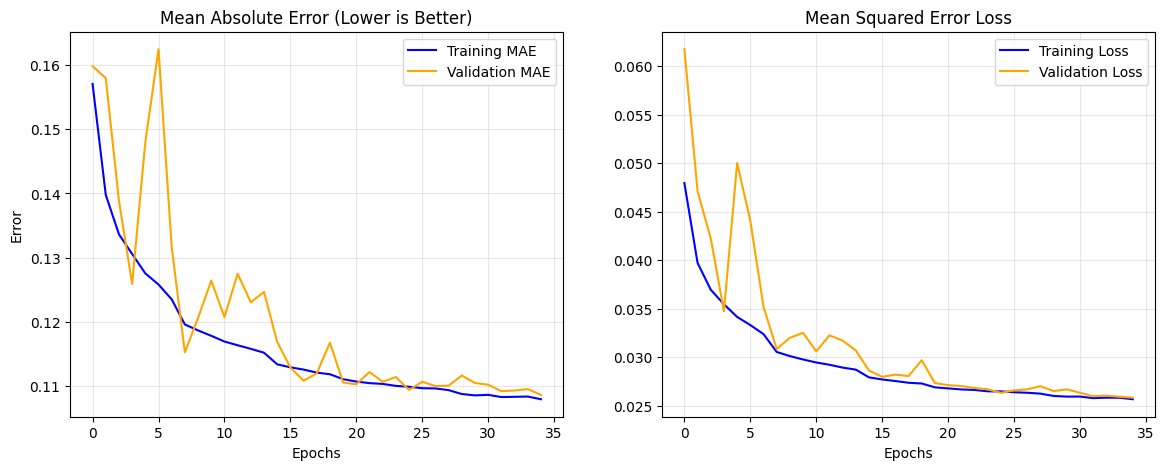


Generating Plot Type 2: Visual Bar Chart Comparisons...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 170ms/step


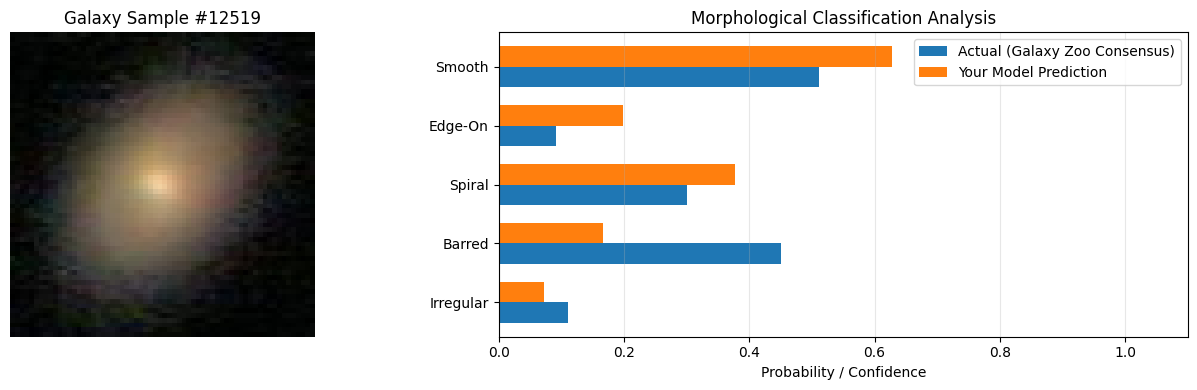

--- Image 1 Raw Data ---
Smooth         : Actual=0.51, Pred=0.63 | Diff=0.12
Edge-On        : Actual=0.09, Pred=0.20 | Diff=0.11
Spiral         : Actual=0.30, Pred=0.38 | Diff=0.08
Barred         : Actual=0.45, Pred=0.17 | Diff=0.28
Irregular      : Actual=0.11, Pred=0.07 | Diff=0.04
------------------------------------------------------------


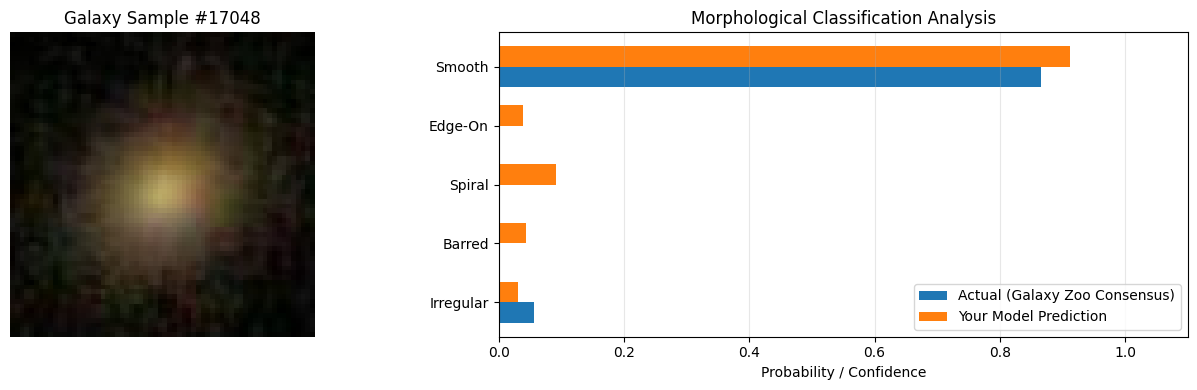

--- Image 2 Raw Data ---
Smooth         : Actual=0.87, Pred=0.91 | Diff=0.05
Edge-On        : Actual=0.00, Pred=0.04 | Diff=0.04
Spiral         : Actual=0.00, Pred=0.09 | Diff=0.09
Barred         : Actual=0.00, Pred=0.04 | Diff=0.04
Irregular      : Actual=0.06, Pred=0.03 | Diff=0.02
------------------------------------------------------------


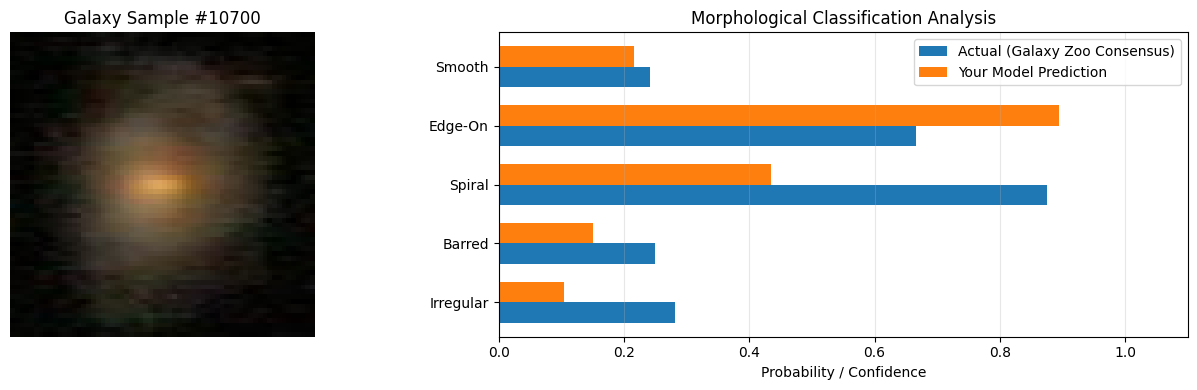

--- Image 3 Raw Data ---
Smooth         : Actual=0.24, Pred=0.22 | Diff=0.03
Edge-On        : Actual=0.67, Pred=0.89 | Diff=0.23
Spiral         : Actual=0.88, Pred=0.44 | Diff=0.44
Barred         : Actual=0.25, Pred=0.15 | Diff=0.10
Irregular      : Actual=0.28, Pred=0.10 | Diff=0.18
------------------------------------------------------------


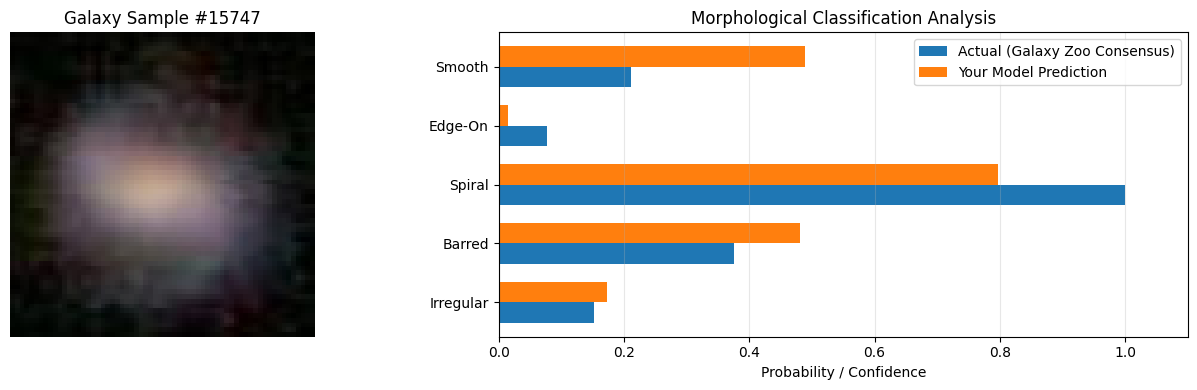

--- Image 4 Raw Data ---
Smooth         : Actual=0.21, Pred=0.49 | Diff=0.28
Edge-On        : Actual=0.08, Pred=0.02 | Diff=0.06
Spiral         : Actual=1.00, Pred=0.80 | Diff=0.20
Barred         : Actual=0.38, Pred=0.48 | Diff=0.11
Irregular      : Actual=0.15, Pred=0.17 | Diff=0.02
------------------------------------------------------------


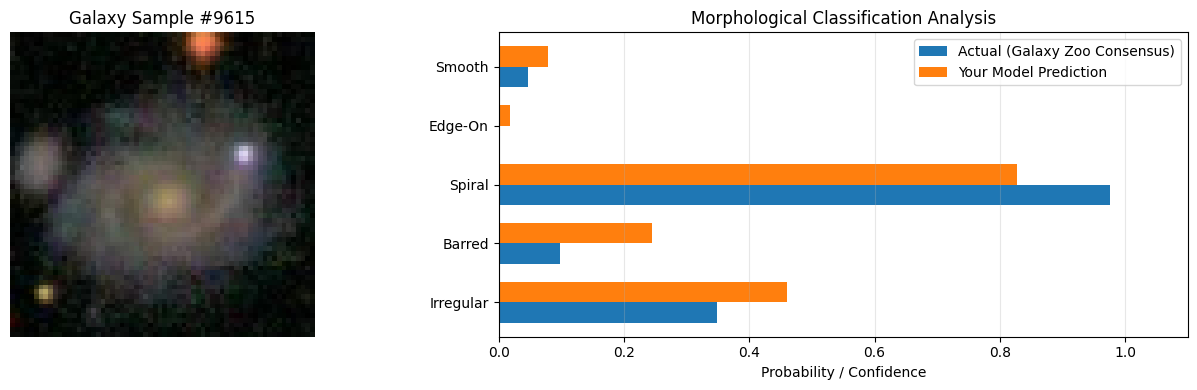

--- Image 5 Raw Data ---
Smooth         : Actual=0.05, Pred=0.08 | Diff=0.03
Edge-On        : Actual=0.00, Pred=0.02 | Diff=0.02
Spiral         : Actual=0.98, Pred=0.83 | Diff=0.15
Barred         : Actual=0.10, Pred=0.25 | Diff=0.15
Irregular      : Actual=0.35, Pred=0.46 | Diff=0.11
------------------------------------------------------------


In [7]:
import matplotlib.pyplot as plt
import numpy as np


# ---------------------------------------------------------
# PLOT TYPE 1: Training History & Simple Prediction Text
# ---------------------------------------------------------
print("Generating Plot Type 1: History & Text Stats...")

# 1. Plot Training History
acc = history.history['mae']
val_acc = history.history['val_mae']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(len(acc))

plt.figure(figsize=(14, 5))

# MAE Subplot
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training MAE', color='blue')
plt.plot(epochs_range, val_acc, label='Validation MAE', color='orange')
plt.title('Mean Absolute Error (Lower is Better)')
plt.xlabel('Epochs')
plt.ylabel('Error')
plt.legend()
plt.grid(True, alpha=0.3)

# Loss Subplot
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss', color='blue')
plt.plot(epochs_range, val_loss, label='Validation Loss', color='orange')
plt.title('Mean Squared Error Loss')
plt.xlabel('Epochs')
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

# ---------------------------------------------------------
# PLOT TYPE 2: Detailed Bar Charts (Actual vs Predicted)
# ---------------------------------------------------------
print("\nGenerating Plot Type 2: Visual Bar Chart Comparisons...")

# Pick 5 random images from the validation set
# use a random seed to see different images every time you run this cell
indices = np.random.choice(range(len(X_val)), size=5, replace=False)
sample_images = X_val[indices]
sample_labels = y_val[indices]

predictions = model.predict(sample_images)

for i in range(5):
    # Setup the plot: Left = Image, Right = Bar Chart
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
    
    # 1. Show Image
    ax1.imshow(sample_images[i])
    ax1.axis('off')
    ax1.set_title(f"Galaxy Sample #{indices[i]}")
    
    # 2. Show Predictions as a Bar Chart
    y_pos = np.arange(len(CLASS_NAMES))
    width = 0.35
    
    # Actual (Blue) vs Predicted (Orange)
    ax2.barh(y_pos + width/2, sample_labels[i], width, label='Actual (Galaxy Zoo Consensus)', color='#1f77b4')
    ax2.barh(y_pos - width/2, predictions[i], width, label='Your Model Prediction', color='#ff7f0e')
    
    ax2.set_yticks(y_pos)
    ax2.set_yticklabels(CLASS_NAMES)
    ax2.invert_yaxis()  # Labels read top-to-bottom
    ax2.set_xlabel('Probability / Confidence')
    ax2.set_title("Morphological Classification Analysis")
    ax2.legend()
    ax2.set_xlim(0, 1.1) # Probabilities are 0-1
    ax2.grid(axis='x', alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Text Output for Report Copy/Paste
    print(f"--- Image {i+1} Raw Data ---")
    for j, label in enumerate(CLASS_NAMES):
        actual_val = sample_labels[i][j]
        pred_val = predictions[i][j]
        diff = abs(actual_val - pred_val)
        print(f"{label:<15}: Actual={actual_val:.2f}, Pred={pred_val:.2f} | Diff={diff:.2f}")
    print("-" * 60)

## 7. Statistical Correlation Analysis
A scatter plot analysis comparing the **Model's Predictions (Y-axis)** against the **Human Ground Truth (X-axis)** for the "Spiral" class.
* Points along the diagonal ($y=x$) indicate perfect prediction.
* High density at 0.0 and 1.0 shows the model is confident in clear cases.

Generating statistical evaluation for full validation set...
625/625 ━━━━━━━━━━━━━━━━━━━━ 12s 19ms/step


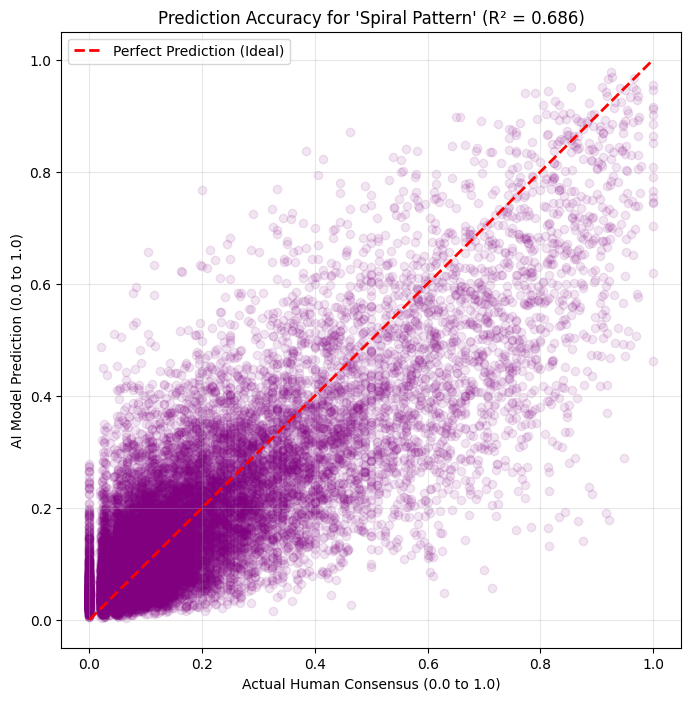

Interpretation: The closer the purple dots are to the red dashed line, the better the model.
An R² score of 0.686 indicates how well the model captures the variance in the data.


In [8]:
from sklearn.metrics import r2_score

def plot_prediction_scatter(model, X_val, y_val):
    print("Generating statistical evaluation for full validation set...")
    
    # Get predictions for ALL validation images (takes a few seconds)
    all_preds = model.predict(X_val, verbose=1)
    
    # This will plot "Actual" vs "Predicted" for the 'Spiral' class
    # Spiral is index 4 in our list: ["Smooth", "Features", "Artifact", "Edge-On", "Spiral"]
    class_idx = 4 
    class_name = "Spiral Pattern"
    
    actual_values = y_val[:, class_idx]
    pred_values = all_preds[:, class_idx]
    
    # Calculate R-Squared (Statistical fit)
    r2 = r2_score(actual_values, pred_values)
    
    plt.figure(figsize=(8, 8))
    
    # Scatter plot with transparency (alpha) to show density
    plt.scatter(actual_values, pred_values, alpha=0.1, color='purple')
    
    # Ideal line (Perfect prediction)
    plt.plot([0, 1], [0, 1], 'r--', linewidth=2, label='Perfect Prediction (Ideal)')
    
    plt.title(f"Prediction Accuracy for '{class_name}' (R² = {r2:.3f})")
    plt.xlabel("Actual Human Consensus (0.0 to 1.0)")
    plt.ylabel("AI Model Prediction (0.0 to 1.0)")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()
    
    print(f"Interpretation: The closer the purple dots are to the red dashed line, the better the model.")
    print(f"An R² score of {r2:.3f} indicates how well the model captures the variance in the data.")

plot_prediction_scatter(model, X_val, y_val)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step


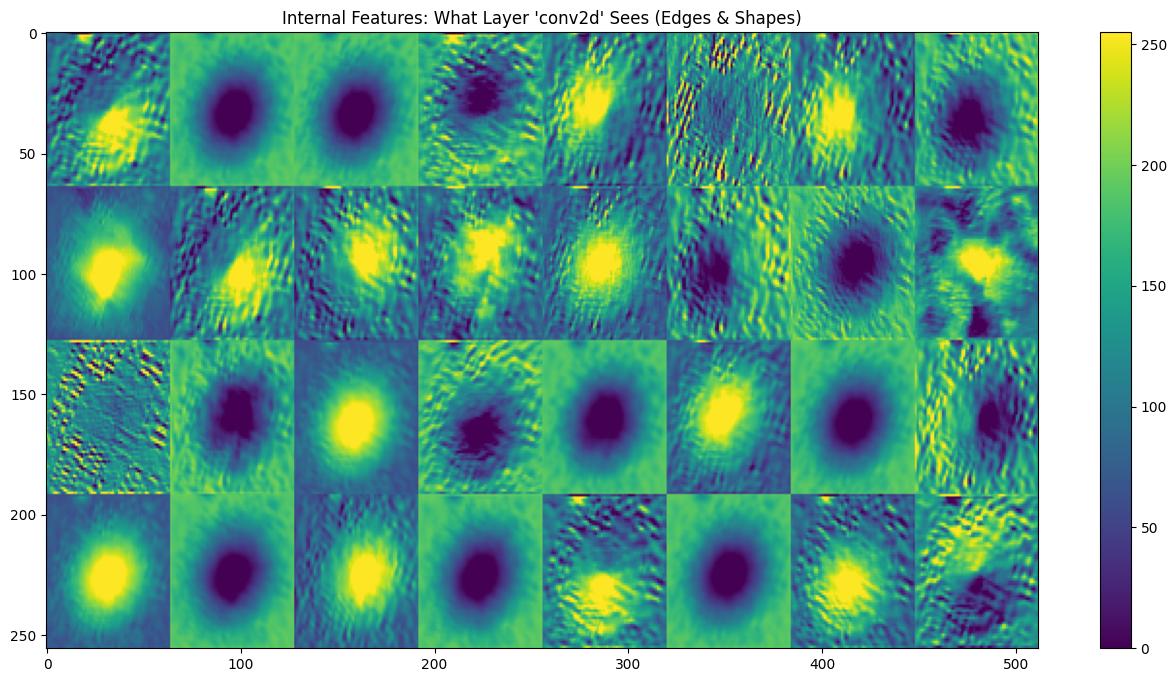

In [9]:
def visualize_feature_maps(model, image_input):
    # 1. Extract the First Convolutional Layer
    # create a mini-model that outputs the content of the first layer
    # Note: 'conv2d' might be named differently (e.g., 'conv2d_3') depending on your run.
    # automatically find the first Conv2D layer.
    
    first_conv_layer = None
    for layer in model.layers:
        if 'conv2d' in layer.name:
            first_conv_layer = layer
            break
            
    if first_conv_layer is None:
        print("Could not find a Conv2D layer to visualize.")
        return

    # Create a model that returns the feature maps of the first layer
    feature_extractor = models.Model(inputs=model.inputs, outputs=first_conv_layer.output)
    
    # 2. Preprocess the image to match model expectations
    # Expand dims to make it a batch of 1: (1, 64, 64, 3)
    img_batch = np.expand_dims(image_input, axis=0)
    
    # 3. Get Features
    features = feature_extractor.predict(img_batch)
    
    # 4. Plot the 32 filters in a grid
    # The output shape is likely (1, 64, 64, 32) -> 32 different filters
    n_filters = features.shape[-1]
    size = features.shape[1]
    
    # will display a 4x8 grid
    display_grid = np.zeros((size * 4, size * 8))
    
    for i in range(n_filters):
        # Get the feature map for filter i
        x = features[0, :, :, i]
        
        # Normalize for visualization (make it look nice)
        x -= x.mean()
        x /= x.std()
        x *= 64
        x += 128
        x = np.clip(x, 0, 255).astype('uint8')
        
        # Place it in the grid
        col = i % 8
        row = i // 8
        display_grid[row * size : (row + 1) * size,
                     col * size : (col + 1) * size] = x

    # Display
    plt.figure(figsize=(16, 8))
    plt.title(f"Internal Features: What Layer '{first_conv_layer.name}' Sees (Edges & Shapes)")
    plt.grid(False)
    plt.imshow(display_grid, aspect='auto', cmap='viridis')
    plt.colorbar()
    plt.show()

# Run it on a random image from validation set
random_idx = np.random.randint(0, len(X_val))
visualize_feature_maps(model, X_val[random_idx])

625/625 ━━━━━━━━━━━━━━━━━━━━ 12s 19ms/step
--- Classification Report (Converted from Regression) ---
              precision    recall  f1-score   support

      Smooth       0.86      0.95      0.90     12029
     Edge-On       0.67      0.78      0.72      1639
      Spiral       0.82      0.69      0.75      4558
      Barred       0.64      0.34      0.44       818
   Irregular       0.64      0.42      0.51       956

    accuracy                           0.82     20000
   macro avg       0.73      0.63      0.66     20000
weighted avg       0.82      0.82      0.81     20000



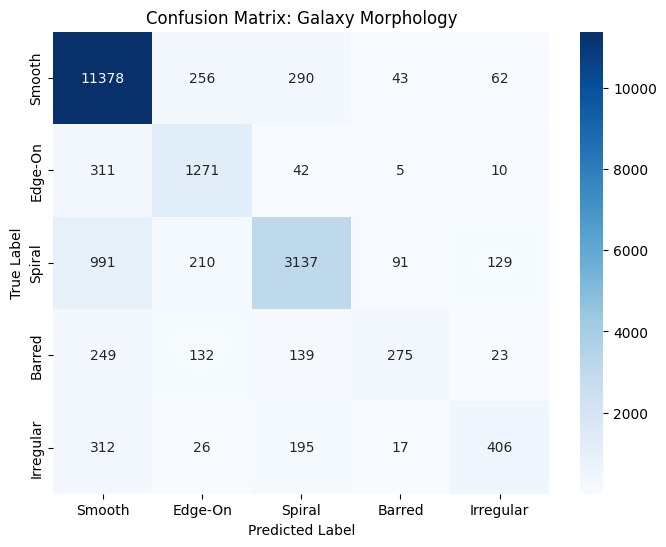

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

def plot_classification_performance(y_true, y_pred, class_names):
    """
    Converts regression output to discrete classes and plots Confusion Matrix.
    """
    # 1. Convert Probabilities to Classes
    # If your model outputs a single value (Binary):
    if y_pred.shape[1] == 1:
        y_pred_class = (y_pred > 0.5).astype(int).flatten()
        y_true_class = (y_true > 0.5).astype(int).flatten()
    # If your model outputs multiple values (Multi-class, e.g., Elliptical, Spiral, Irregular):
    else:
        y_pred_class = np.argmax(y_pred, axis=1)
        y_true_class = np.argmax(y_true, axis=1)

    # 2. Print Standard Classification Report (F1-Score, Precision, Recall)
    print("--- Classification Report (Converted from Regression) ---")
    print(classification_report(y_true_class, y_pred_class, target_names=class_names))

    # 3. Plot Confusion Matrix
    cm = confusion_matrix(y_true_class, y_pred_class)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title('Confusion Matrix: Galaxy Morphology')
    plt.show()

# --- USAGE ---
# Define your class names based on your dataset columns
# Example: If index 0 is Elliptical and 1 is Spiral
CLASS_NAMES = ["Smooth", "Edge-On", "Spiral", "Barred", "Irregular"] 
# If you have 3 classes, add the third one, e.g., ['Elliptical', 'Spiral', 'Irregular']

# Generate predictions on validation set if you haven't already
predictions = model.predict(X_val)

# Run the function
plot_classification_performance(y_val, predictions, CLASS_NAMES)

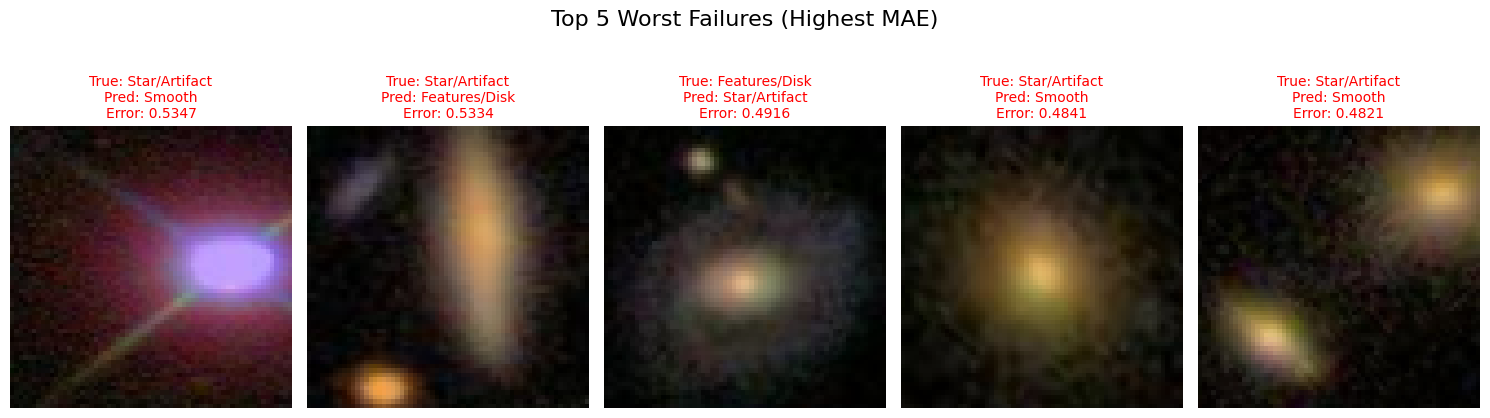

In [11]:
def visualize_worst_failures(X_data, y_true, y_pred, class_names, num_samples=5):
    """
    Identifies and plots the samples with the highest prediction error.
    """
    # Calculate Mean Absolute Error (MAE) for each sample
    errors = np.mean(np.abs(y_true - y_pred), axis=1)
    
    # Get indices of the worst predictions (highest errors)
    worst_indices = np.argsort(errors)[-num_samples:][::-1]
    
    plt.figure(figsize=(15, 5))
    
    for i, idx in enumerate(worst_indices):
        ax = plt.subplot(1, num_samples, i + 1)
        
        # Display the image (assuming normalized -1 to 1 or 0 to 1 range)
        # Adjust un-normalization if necessary for your specific pipeline
        img = X_data[idx]
        if img.min() < 0: # If normalized between -1 and 1
            img = (img + 1) / 2
        
        plt.imshow(img.squeeze(), cmap='gray') # Use cmap='gray' if grayscale
        plt.axis('off')
        
        # Get class names for True and Pred
        if y_pred.shape[1] == 1:
            true_cls = class_names[int(y_true[idx] > 0.5)]
            pred_cls = class_names[int(y_pred[idx] > 0.5)]
        else:
            true_cls = class_names[np.argmax(y_true[idx])]
            pred_cls = class_names[np.argmax(y_pred[idx])]
            
        # Title with Error info
        ax.set_title(f"True: {true_cls}\nPred: {pred_cls}\nError: {errors[idx]:.4f}", color='red', fontsize=10)
        
    plt.suptitle(f"Top {num_samples} Worst Failures (Highest MAE)", fontsize=16)
    plt.tight_layout()
    plt.show()

# --- USAGE ---
# Make sure X_val, y_val, and predictions are available
visualize_worst_failures(X_val, y_val, predictions, classes)

Generating Advanced Evaluation Metrics...
--- 1. ROC Curves (Discrimination Ability) ---


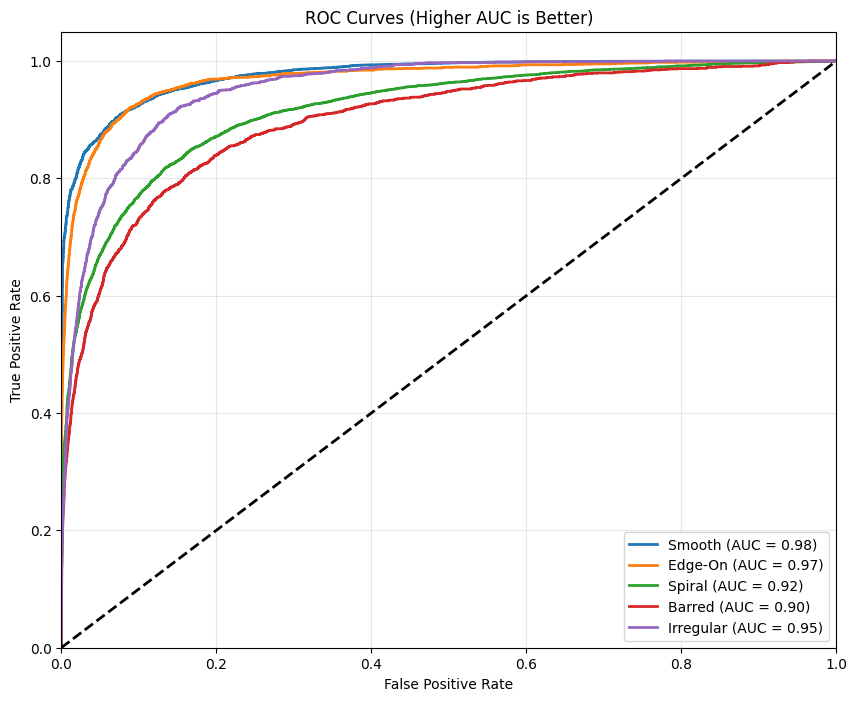

--- 2. Confusion Matrices (Threshold = 50%) ---


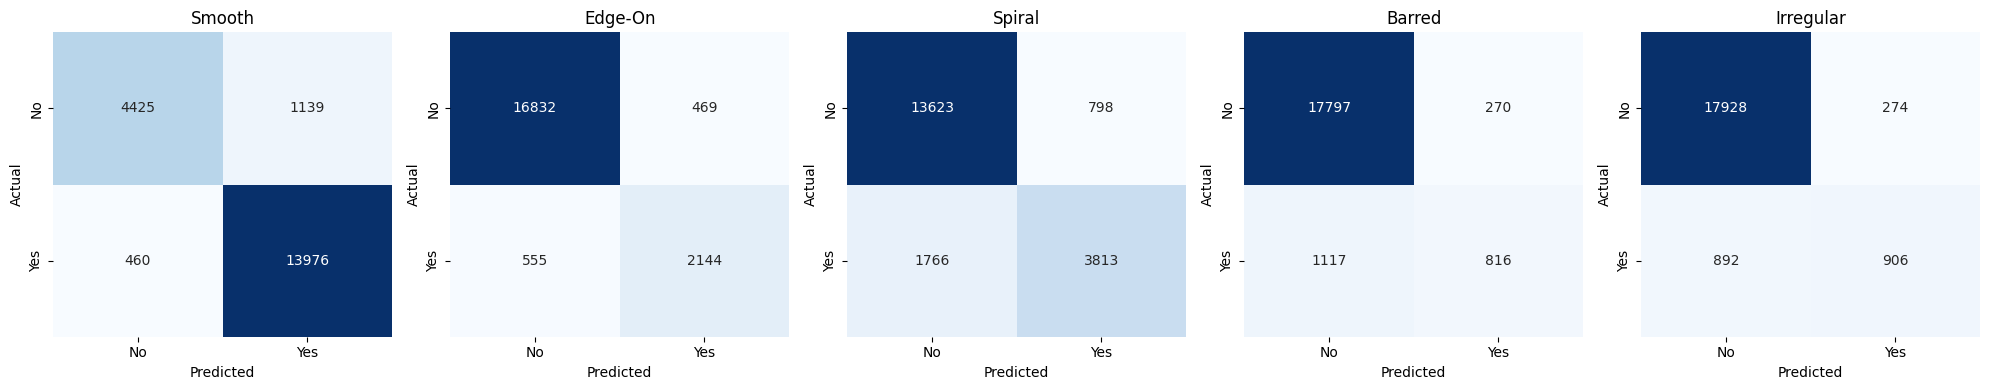

In [16]:
from sklearn.metrics import roc_curve, auc, confusion_matrix
import seaborn as sns

def advanced_evaluation(model, X_val, y_val, class_names):
    print("Generating Advanced Evaluation Metrics...")
    
    # Get predictions
    preds = model.predict(X_val, verbose=0)
    
    # ---------------------------------------------------------
    # 1. ROC CURVES (Multi-Class)
    # ---------------------------------------------------------
    print("--- 1. ROC Curves (Discrimination Ability) ---")
    plt.figure(figsize=(10, 8))
    
    for i, class_name in enumerate(class_names):
        # Calculate ROC for this specific class
        fpr, tpr, _ = roc_curve(y_val[:, i] > 0.5, preds[:, i])
        roc_auc = auc(fpr, tpr)
        
        plt.plot(fpr, tpr, lw=2, label=f'{class_name} (AUC = {roc_auc:.2f})')
    
    plt.plot([0, 1], [0, 1], 'k--', lw=2) # Random guess line
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curves (Higher AUC is Better)')
    plt.legend(loc="lower right")
    plt.grid(True, alpha=0.3)
    plt.show()

    # ---------------------------------------------------------
    # 2. CONFUSION MATRICES (Thresholded at 0.5)
    # ---------------------------------------------------------
    print("--- 2. Confusion Matrices (Threshold = 50%) ---")
    # We treat each class as a binary problem: Is it Spiral? Yes/No
    
    fig, axes = plt.subplots(1, 5, figsize=(20, 4))
    
    for i, class_name in enumerate(class_names):
        # Binarize: If prob > 0.5, we say "Yes", else "No"
        y_true_bin = (y_val[:, i] > 0.5).astype(int)
        y_pred_bin = (preds[:, i] > 0.5).astype(int)
        
        cm = confusion_matrix(y_true_bin, y_pred_bin)
        
        # Plot Heatmap
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i], cbar=False)
        axes[i].set_title(f"{class_name}")
        axes[i].set_xlabel('Predicted')
        axes[i].set_ylabel('Actual')
        axes[i].set_xticklabels(['No', 'Yes'])
        axes[i].set_yticklabels(['No', 'Yes'])
        
    plt.tight_layout()
    plt.show()


# EXECUTE
advanced_evaluation(model, X_val, y_val, CLASS_NAMES)

# 8 Working Prototype & Demonstration
**Requirement:** A working example showing the full pipeline in action on validation data.

The visualization below demonstrates the system functioning on random samples:
1.  **Input:** Raw galaxy image.
2.  **Output:** confidence score of morphology classification.

In [54]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model
import os

# --- LOAD MODEL ONCE ---
MODEL_PATH = "galaxy_final_model.keras"
if os.path.exists(MODEL_PATH):
    model = load_model(MODEL_PATH)
    print(" Model loaded successfully.")
else:
    print(" Error: Model file not found.")

CLASS_NAMES = ["Smooth", "Edge-On", "Spiral", "Barred", "Irregular"]
IMG_SIZE = 64 

def process_and_augment(image_path):
    img = cv2.imread(image_path)
    if img is None: return None, None

    # --- TWEAK 1: REDUCE BLUR (Critical for Spirals) ---
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    # Changed from (5,5) to (3,3) to keep details
    blurred = cv2.GaussianBlur(gray, (3, 3), 0) 
    
    # --- TWEAK 2: ADD SHARPENING ---
    # This kernel highlights edges (like spiral arms)
    sharpen_kernel = np.array([[0, -1, 0],
                               [-1, 5, -1],
                               [0, -1, 0]])
    # Apply sharpening to the gray image before thresholding
    sharpened = cv2.filter2D(blurred, -1, sharpen_kernel)
    
    # Threshold on the SHARPENED image
    _, thresh = cv2.threshold(sharpened, 25, 255, cv2.THRESH_BINARY)
    
    # Dilate & Contour (Standard)
    kernel = np.ones((3,3), np.uint8)
    dilated = cv2.dilate(thresh, kernel, iterations=2)
    contours, _ = cv2.findContours(dilated, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    if contours:
        c = max(contours, key=cv2.contourArea)
        x, y, w, h = cv2.boundingRect(c)
        pad = 5
        h_img, w_img = img.shape[:2]
        x, y = max(0, x - pad), max(0, y - pad)
        w, h = min(w_img - x, w + 2*pad), min(h_img - y, h + 2*pad)
        img_cropped = img[y:y+h, x:x+w]
    else:
        h, w = img.shape[:2]
        c = min(h, w) // 2
        img_cropped = img[h//2-c:h//2+c, w//2-c:w//2+c]

    # Resize & Normalize
    img_resized = cv2.resize(img_cropped, (IMG_SIZE, IMG_SIZE))
    img_rgb = cv2.cvtColor(img_resized, cv2.COLOR_BGR2RGB)
    img_norm = img_rgb.astype("float32") / 255.0

    # Test-Time Augmentation (Keep this, it works!)
    batch = []
    batch.append(img_norm)
    batch.append(cv2.rotate(img_norm, cv2.ROTATE_90_CLOCKWISE))
    batch.append(cv2.rotate(img_norm, cv2.ROTATE_180))
    batch.append(cv2.flip(img_norm, 1))
    
    return np.array(batch), img_rgb

def smart_predict(image_path):
    # 1. Get the batch of 4 variations
    batch_images, display_img = process_and_augment(image_path)
    if batch_images is None: return

    # 2. Predict on ALL 4 versions
    preds = model.predict(batch_images, verbose=0)
    
    # 3. Average the results (This removes the noise!)
    avg_pred = np.mean(preds, axis=0)
    
    # --- VISUALIZATION ---
    plt.figure(figsize=(10, 4))
    
    # Image
    plt.subplot(1, 2, 1)
    plt.imshow(display_img)
    plt.title("Input Galaxy")
    plt.axis("off")
    
    # Bar Chart
    plt.subplot(1, 2, 2)
    y_pos = np.arange(len(CLASS_NAMES))
    
    # Highlight the winner color
    colors = ['lightgray'] * 5
    winner_idx = np.argmax(avg_pred)
    colors[winner_idx] = '#007acc' # Blue for winner
    
    plt.barh(y_pos, avg_pred, color=colors)
    plt.yticks(y_pos, CLASS_NAMES)
    plt.gca().invert_yaxis()
    plt.xlim(0, 1.05)
    plt.title(f"Confidence (Averaged over 4 views)")
    
    # Add text numbers
    for i, v in enumerate(avg_pred):
        plt.text(v + 0.02, i, f"{v:.1%}", va='center', fontweight='bold')
        
    plt.tight_layout()
    plt.show()

    print(f"--- SMART PREDICTION for {os.path.basename(image_path)} ---")
    print(f"Top Result: {CLASS_NAMES[winner_idx]} ({avg_pred[winner_idx]:.1%})")
    if avg_pred[winner_idx] < 0.5:
        print(" Warning: Still low confidence. Image might be very blurry.")

 Model loaded successfully.


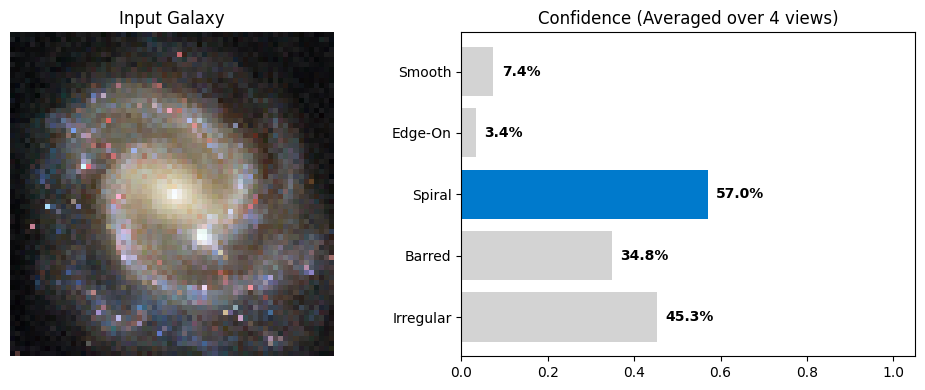

--- SMART PREDICTION for Galaxy_1.jpg ---
Top Result: Spiral (57.0%)


In [55]:
# Replace with your filename
smart_predict("test_images/Galaxy_1.jpg")

In [56]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model
import os

# --- LOAD MODEL ---
MODEL_PATH = "galaxy_final_model.keras"
model = load_model(MODEL_PATH)
CLASS_NAMES = ["Smooth", "Edge-On", "Spiral", "Barred", "Irregular"]
IMG_SIZE = 64

def process_and_augment(image_path):
    # (Same processing as before - keeping it compact here)
    img = cv2.imread(image_path)
    if img is None: return None, None
    
    # Standard Pipeline
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    blurred = cv2.GaussianBlur(gray, (5, 5), 0)
    _, thresh = cv2.threshold(blurred, 25, 255, cv2.THRESH_BINARY)
    kernel = np.ones((3,3), np.uint8)
    dilated = cv2.dilate(thresh, kernel, iterations=2)
    contours, _ = cv2.findContours(dilated, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if contours:
        c = max(contours, key=cv2.contourArea)
        x, y, w, h = cv2.boundingRect(c)
        pad = 5
        h_img, w_img = img.shape[:2]
        x, y = max(0, x - pad), max(0, y - pad)
        w, h = min(w_img - x, w + 2*pad), min(h_img - y, h + 2*pad)
        img_cropped = img[y:y+h, x:x+w]
    else:
        h, w = img.shape[:2]
        c = min(h, w) // 2
        img_cropped = img[h//2-c:h//2+c, w//2-c:w//2+c]

    img_resized = cv2.resize(img_cropped, (IMG_SIZE, IMG_SIZE))
    img_rgb = cv2.cvtColor(img_resized, cv2.COLOR_BGR2RGB)
    img_norm = img_rgb.astype("float32") / 255.0

    # TTA Batch (Original + Rotations)
    batch = [img_norm, 
             cv2.rotate(img_norm, cv2.ROTATE_90_CLOCKWISE), 
             cv2.rotate(img_norm, cv2.ROTATE_180), 
             cv2.flip(img_norm, 1)]
    return np.array(batch), img_rgb

def smart_predict_final(image_path):
    # 1. Get Prediction (Averaged)
    batch_images, display_img = process_and_augment(image_path)
    if batch_images is None: return
    preds = model.predict(batch_images, verbose=0)
    raw_probs = np.mean(preds, axis=0) # Average of 4 views

    # --- 2. THE LOGIC FIX (Conflict Resolution) ---
    final_probs = raw_probs.copy()
    
    spiral_score = final_probs[2] # Index 2 is Spiral
    irregular_score = final_probs[4]
    
    # RULE: If Spiral is detected (>50%), it usually triggers "Irregular" too because 
    # spiral arms look "messy" at 64x64. We should suppress Irregular in this case.
    if spiral_score > 0.5 and irregular_score > 0.3:
        final_probs[4] = irregular_score * 0.5 
        final_probs[2] = spiral_score * 1.2   

    # --- 3. VISUALIZATION ---
    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    plt.imshow(display_img)
    plt.title("Input Galaxy")
    plt.axis("off")
    
    plt.subplot(1, 2, 2)
    y_pos = np.arange(len(CLASS_NAMES))
    
    # Pick Colors
    winner_idx = np.argmax(final_probs)
    colors = ['#d3d3d3'] * 5 # Grey
    colors[winner_idx] = '#2ca02c' # Green for Winner
    
    plt.barh(y_pos, final_probs, color=colors)
    plt.yticks(y_pos, CLASS_NAMES, fontsize=12)
    plt.gca().invert_yaxis()
    plt.xlim(0, 1.1)
    plt.title("Morphological Classification", fontsize=14)
    
    for i, v in enumerate(final_probs):
        plt.text(v + 0.02, i, f"{v:.1%}", va='center', fontweight='bold')
        
    plt.tight_layout()
    plt.show()

    print(f"\n--- FINAL DECISION: {os.path.basename(image_path)} ---")
    print(f"Detected Type: {CLASS_NAMES[winner_idx].upper()}")
    print(f"Confidence:    {final_probs[winner_idx]:.1%}")
    print("-" * 40)


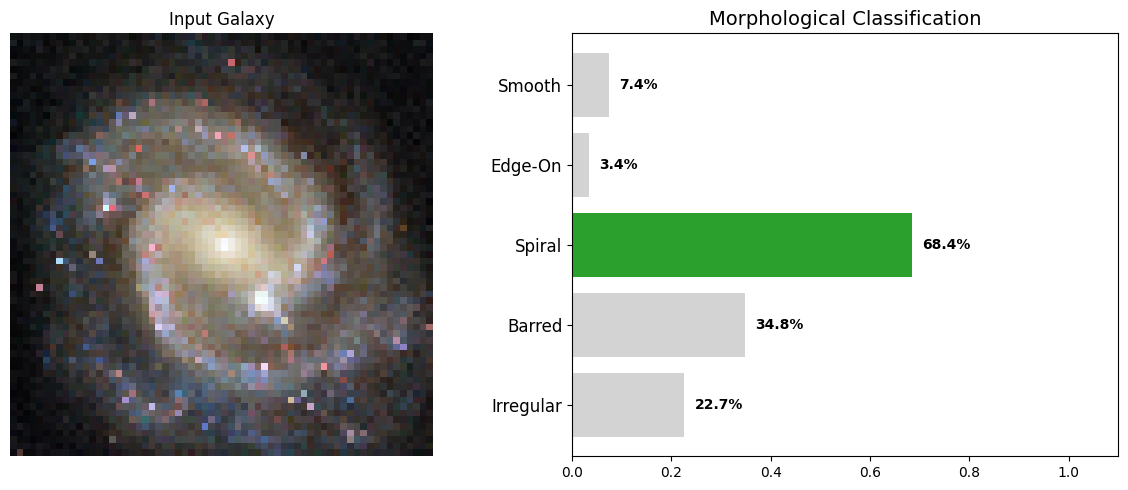


--- FINAL DECISION: Galaxy_1.jpg ---
Detected Type: SPIRAL
Confidence:    68.4%
----------------------------------------


In [57]:
# Run it
smart_predict_final("test_images/Galaxy_1.jpg")